In [1]:
# 모듈 Import
import os
import glob
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

plt.rcParams['font.family'] = 'Malgun Gothic' # Mac 사용자라면 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

warnings.filterwarnings(action='ignore') 
pd.set_option('display.max_column', 20)
pd.set_option('display.max_row', 100)

In [3]:
# 데이터 불러오기
df = pd.read_csv("../dataset/Building Energy Efficiency.csv")
df

,Relative Compactness,Surface Area,Wall Area,Roof Area,Overall Height,Orientation,Glazing Area,Glazing Area Distribution,Heating Load,Cooling Load
0,0.7638,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.9800,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.9800,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.9800,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.9000,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28
...,...,...,...,...,...,...,...,...,...,...
763,0.6400,784.0,343.0,220.50,3.5,5,0.4,5,17.88,21.40
764,0.6200,808.5,367.5,220.50,3.5,2,0.4,5,16.54,16.88
765,0.6200,808.5,367.5,220.50,3.5,3,0.4,5,16.44,17.11
766,0.6200,808.5,367.5,220.50,3.5,4,0.4,5,16.48,16.61


### 이 데이터셋은 다음과 같은 특성(feature)들을 포함합니다.

- **X1, 상대 밀집도 (Relative Compactness): 건물 형태의 밀집 정도를 나타내는 척도.
- **X2, 표면적 (Surface Area): 건물의 외부 표면적.
- **X3, 벽 면적 (Wall Area): 건물의 전체 벽 면적.
- **X4, 지붕 면적 (Roof Area): 건물의 지붕 면적.
- **X5, 전체 높이 (Overall Height): 건물의 높이.
- **X6, 방향 (Orientation) (정수): 건물이 향하는 방향.
- **X7, 창호 면적 (Glazing Area): 유리로 된 표면(창문)의 전체 면적.
- **X8, 창호 면적 분포 (Glazing Area Distribution) (정수): 방향별 창호 면적의 분포.

목표 변수(target variable)는 다음과 같습니다.

- **난방 부하 (Heating Load, Y1): 난방에 필요한 에너지.
- **냉방 부하 (Cooling Load, Y2): 냉방에 필요한 에너지.

In [ ]:
# 데이터 정보 확인
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Relative Compactness       768 non-null    float64
 1   Surface Area               768 non-null    float64
 2   Wall Area                  768 non-null    float64
 3   Roof Area                  768 non-null    float64
 4   Overall Height             768 non-null    float64
 5   Orientation                768 non-null    int64  
 6   Glazing Area               768 non-null    float64
 7   Glazing Area Distribution  768 non-null    int64  
 8   Heating Load               768 non-null    float64
 9   Cooling Load               768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


In [6]:
# 데이터 크기 확인
df.shape

(768, 10)

In [7]:
df.columns

Index(['Relative Compactness', 'Surface Area', 'Wall Area', 'Roof Area',
       'Overall Height', 'Orientation', 'Glazing Area',
       'Glazing Area Distribution', 'Heating Load', 'Cooling Load'],
      dtype='str')

In [8]:
df.isna().sum()

Relative Compactness         0
Surface Area                 0
Wall Area                    0
Roof Area                    0
Overall Height               0
Orientation                  0
Glazing Area                 0
Glazing Area Distribution    0
Heating Load                 0
Cooling Load                 0
dtype: int64

# 사계절 동적 에너지 시뮬레이션

데이터 기간: 2017-01-01 00:00:00 ~ 2018-12-31 23:00:00
총 데이터 포인트: 277243개 (시간당 기록)


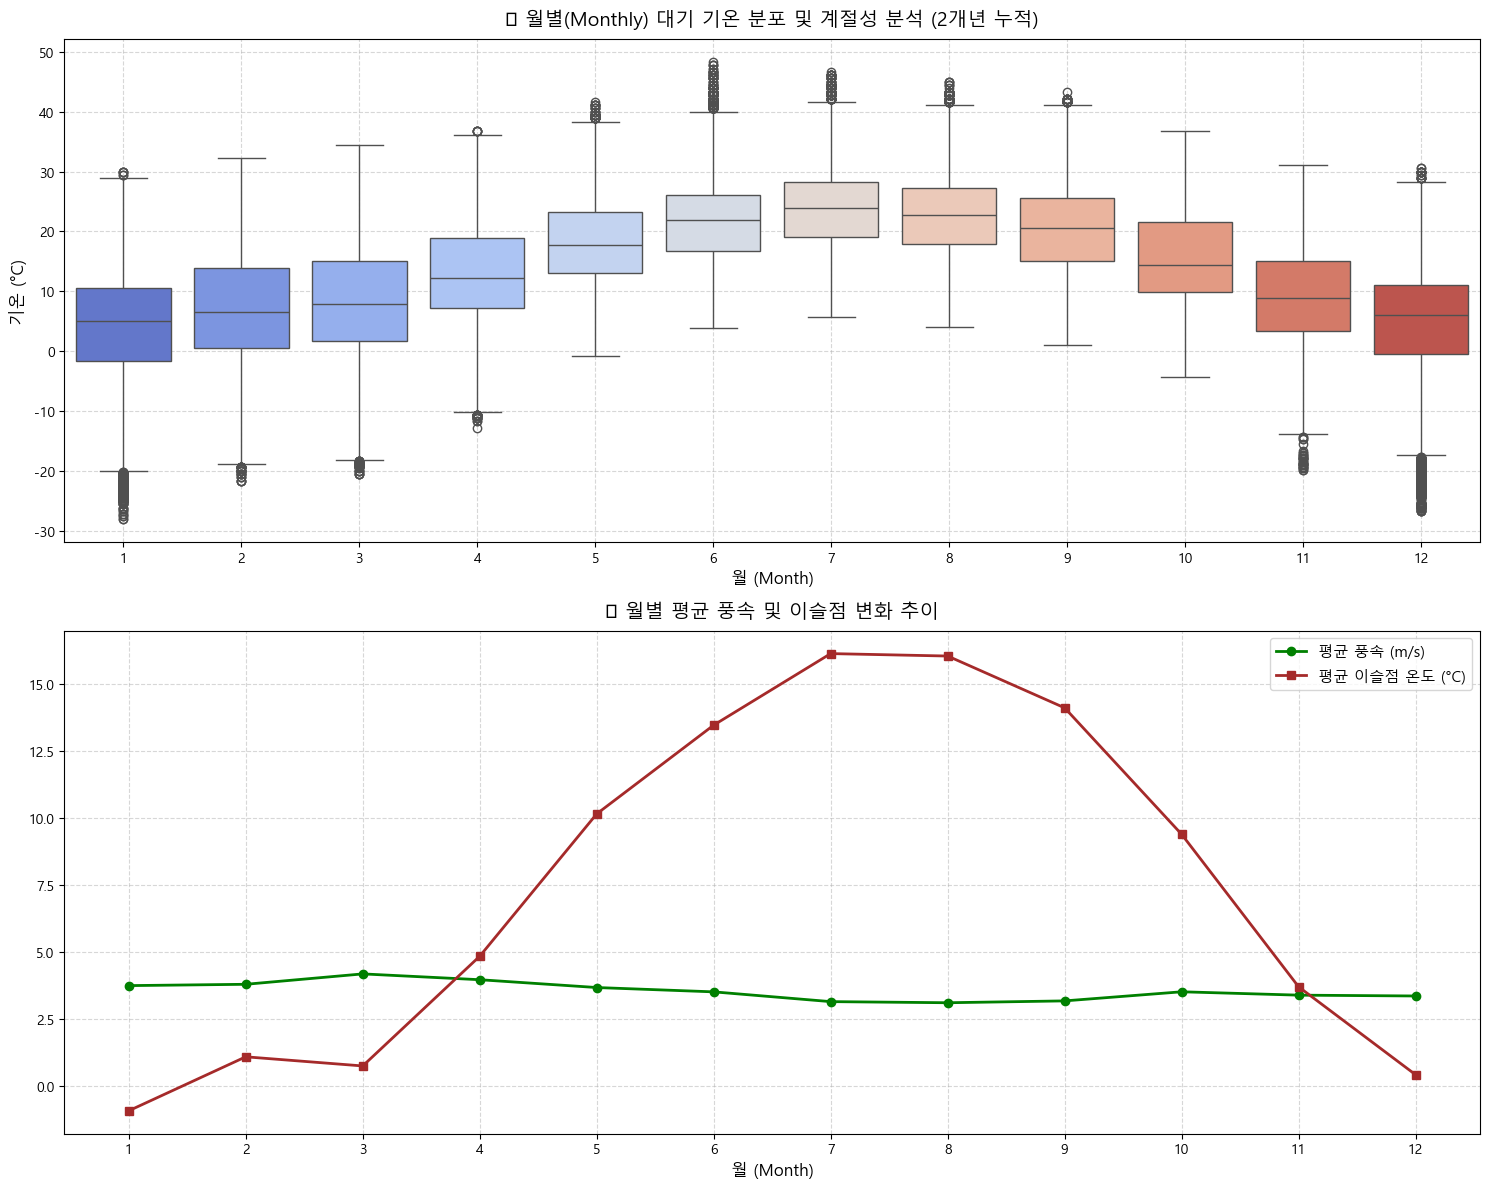

<Figure size 1400x600 with 0 Axes>

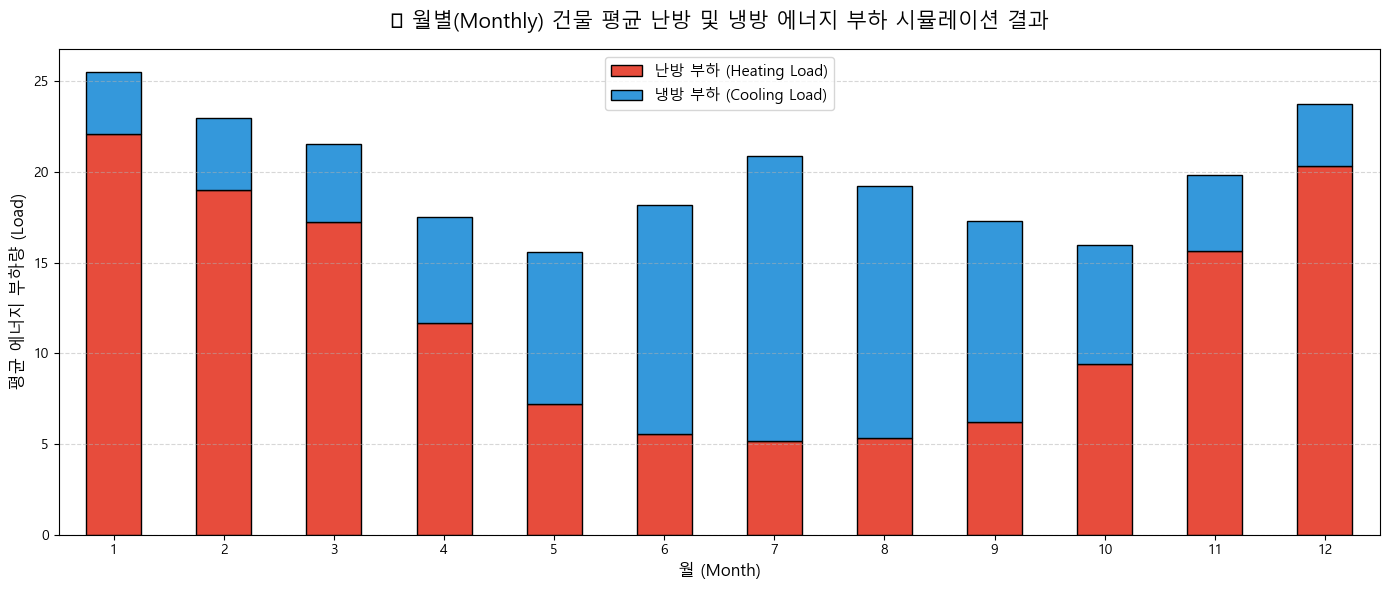

In [10]:
# ==========================================
# 1. 대용량 기후 데이터 로드 및 전처리
# ==========================================
# 데이터가 크므로 필요한 컬럼 위주로 파싱합니다.
df = pd.read_csv('../dataset/weather_test.csv', parse_dates=['timestamp'])
df.set_index('timestamp', inplace=True)

# 분석을 위한 시간 파생 변수 생성 (달, 시간, 연도)
df['Month'] = df.index.month
df['Hour'] = df.index.hour
df['Year'] = df.index.year

# 결측치가 있을 경우 선형 보간법으로 채웁니다.
df['air_temperature'] = df['air_temperature'].interpolate(method='linear')

print(f"데이터 기간: {df.index.min()} ~ {df.index.max()}")
print(f"총 데이터 포인트: {len(df)}개 (시간당 기록)")

# ==========================================
# 2. [핵심 요청] 달별(Monthly) 기후 패턴 분석 및 시각화
# ==========================================
plt.rcParams['font.family'] = 'Malgun Gothic' # Mac 유저는 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(2, 1, figsize=(15, 12))

# 2-1. 달별 기온 분포 (Boxplot) -> 계절 변화를 가장 잘 보여줍니다.
sns.boxplot(data=df, x='Month', y='air_temperature', ax=axes[0], palette='coolwarm')
axes[0].set_title('📊 월별(Monthly) 대기 기온 분포 및 계절성 분석 (2개년 누적)', fontsize=14, pad=10)
axes[0].set_xlabel('월 (Month)', fontsize=12)
axes[0].set_ylabel('기온 (°C)', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.5)

# 2-2. 달별 평균 풍속 및 이슬점 온도 추이 (Lineplot)
monthly_mean = df.groupby('Month')[['air_temperature', 'wind_speed', 'dew_temperature']].mean().reset_index()
axes[1].plot(monthly_mean['Month'], monthly_mean['wind_speed'], marker='o', color='green', linewidth=2, label='평균 풍속 (m/s)')
axes[1].plot(monthly_mean['Month'], monthly_mean['dew_temperature'], marker='s', color='brown', linewidth=2, label='평균 이슬점 온도 (°C)')
axes[1].set_title('📈 월별 평균 풍속 및 이슬점 변화 추이', fontsize=14, pad=10)
axes[1].set_xlabel('월 (Month)', fontsize=12)
axes[1].set_xticks(range(1, 13))
axes[1].legend(loc='upper right', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# ==========================================
# 3. 기존 모델 개념 융합: 사계절 동적 에너지 시뮬레이션
# ==========================================
def simulate_yearly_energy(weather_data, glazing_area=0.2):
    """
    달별 실제 기온을 기반으로 기존 머신러닝의 다중 출력(냉방/난방 부하) 성향을 시뮬레이션합니다.
    - 기온이 낮을수록(겨울) 난방 부하 증가
    - 기온이 높을수록(여름) 냉방 부하 증가
    - 창문 면적이 넓을수록 여름철 냉방 부담 가중
    """
    sim_df = pd.DataFrame(index=weather_data.index)
    sim_df['Month'] = weather_data['Month']
    
    # 가상 모델 수식 (기존 랜덤 포레스트의 예측 메커니즘 모사)
    # 기온이 15도 이하일 때 난방 부하가 주로 발생한다고 가정
    sim_df['Heating_Load'] = np.where(weather_data['air_temperature'] < 15, (15 - weather_data['air_temperature']) * 1.5, 0)
    # 기온이 20도 이상일 때 냉방 부하가 주로 발생한다고 가정 (창문 면적 비례 가중치)
    sim_df['Cooling_Load'] = np.where(weather_data['air_temperature'] > 20, (weather_data['air_temperature'] - 20) * 2.0 * (1 + glazing_area), 0)
    
    # 건물 구조에 의한 기본 유지 부하 추가
    sim_df['Heating_Load'] += 5.0
    sim_df['Cooling_Load'] += 3.0
    sim_df['Total_Load'] = sim_df['Heating_Load'] + sim_df['Cooling_Load']
    
    return sim_df

# 시뮬레이션 실행 (창문 면적 0.25 기준)
energy_sim_results = simulate_yearly_energy(df, glazing_area=0.25)

# ==========================================
# 4. 달별(Monthly) 총 에너지 소비량 최종 시각화
# ==========================================
# 달별로 에너지 소모량을 그룹화하여 합산 또는 평균을 냅니다.
monthly_energy = energy_sim_results.groupby('Month')[['Heating_Load', 'Cooling_Load']].mean()

plt.figure(figsize=(14, 6))
monthly_energy.plot(kind='bar', stacked=True, color=['#e74c3c', '#3498db'], figsize=(14, 6), edgecolor='black')
plt.title('🏢 월별(Monthly) 건물 평균 난방 및 냉방 에너지 부하 시뮬레이션 결과', fontsize=15, pad=15)
plt.xlabel('월 (Month)', fontsize=12)
plt.ylabel('평균 에너지 부하량 (Load)', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(['난방 부하 (Heating Load)', '냉방 부하 (Cooling Load)'], loc='upper center', fontsize=11)
plt.tight_layout()
plt.show()